# Projeto 01: Crédito Inteligente

<h3>Integrantes:</h3> Leonardo Nakashima, João Pedro Paulino, Isadora Jardim, Jefferson Lopes e Maria Eduarda

## Importando as bibliotecas 

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
from datetime import datetime
import openpyxl
import os

# Criando o dataFrame com o credito_banco.csv

In [34]:
df = pd.read_csv('clientes_credito_v2.csv')

## ETAPA 1: Limpeza dos dados com pandas

In [35]:
print("=== ETAPA 1: Limpeza dos dados com pandas ===\n")

print(f"Dataset original: {df.shape}")
print(f"Valores ausentes:\n{df.isnull().sum()}")

# Removend valores nulos
df_clean = df.dropna()
print(f"\nApós remover valores ausentes: {df_clean.shape}")

# Removendo rendas outliers
Q1 = df_clean['renda_anual'].quantile(0.25)
Q3 = df_clean['renda_anual'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['renda_anual'] < limite_inf) | (df_clean['renda_anual'] > limite_sup)]
print(f"Outliers de renda detectados: {len(outliers)}")

df_clean = df_clean[(df_clean['renda_anual'] >= limite_inf) & (df_clean['renda_anual'] <= limite_sup)]
print(f"Dataset após remover outliers: {df_clean.shape}")

print(f"\nDistribuição de inadimplência:")
print(f"  Adimplentes: {(df_clean['inadimplente'] == 0).sum()}")
print(f"  Inadimplentes: {(df_clean['inadimplente'] == 1).sum()}")
print(f"  Taxa: {df_clean['inadimplente'].mean()*100:.1f}%")


=== ETAPA 1: Limpeza dos dados com pandas ===

Dataset original: (1000, 7)
Valores ausentes:
id_cliente             0
idade                  0
renda_anual            0
divida_atual           0
historico_pagamento    0
score_externo          0
inadimplente           0
dtype: int64

Após remover valores ausentes: (1000, 7)
Outliers de renda detectados: 0
Dataset após remover outliers: (1000, 7)

Distribuição de inadimplência:
  Adimplentes: 820
  Inadimplentes: 180
  Taxa: 18.0%


#  ETAPA 2: Gerando gráficos
## Gerando histograma com Matplotlib

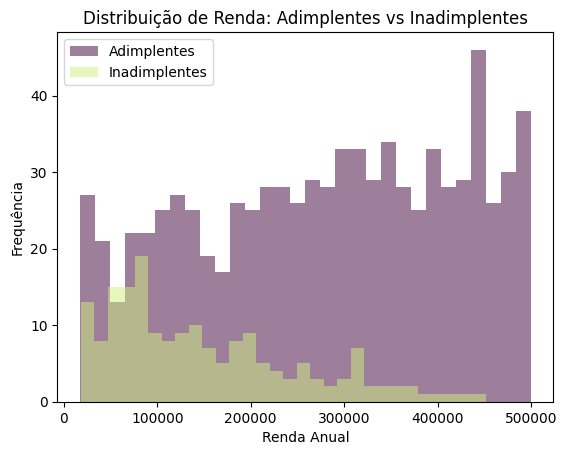

In [36]:
adimplentes = df_clean[df_clean['inadimplente'] == 0]['renda_anual']
inadimplentes = df_clean[df_clean['inadimplente'] == 1]['renda_anual']

plt.figure()

plt.hist (adimplentes, bins=30, alpha=0.5, label='Adimplentes', color='#3D003B')
plt.hist (inadimplentes, bins=30, alpha=0.5, label='Inadimplentes', color='#D1F07F')
plt.xlabel('Renda Anual')
plt.ylabel('Frequência')
plt.title('Distribuição de Renda: Adimplentes vs Inadimplentes')
plt.legend()

plt.show()

## Gerando heatmap com Seaborn

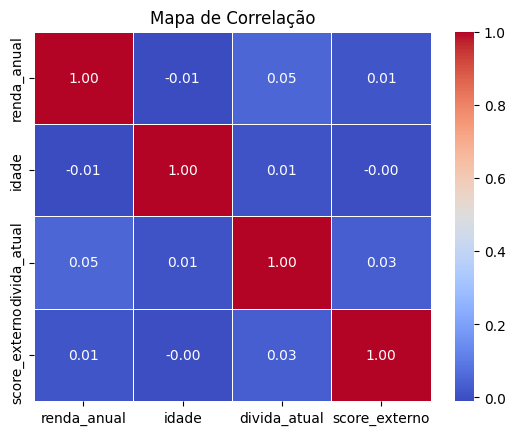

In [37]:
cols = ['renda_anual', 'idade', 'divida_atual', 'score_externo']
corr = df_clean[cols].corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Mapa de Correlação')
plt.show()

## ETAPA 3: Treinar Robô e Automatizar a exportação.

In [ ]:
print("\n=== ETAPA 3.1: Treinando o Modelo de Machine Learning (Random Forest) ===")

def classificar_risco(row):
    pontuacao_risco = 0
    
    if row['renda_anual'] > 150000:
        pontuacao_risco -= 1
    elif row['renda_anual'] < 50000:
        pontuacao_risco += 1
        
    if row['historico_pagamento'] > 70:
        pontuacao_risco -= 1
    elif row['historico_pagamento'] < 30:
        pontuacao_risco += 1

    if row['divida_atual'] > 20000:
        pontuacao_risco += 1
    elif row['divida_atual'] < 5000:
        pontuacao_risco -= 1
        
    return 1 if pontuacao_risco >= 1 else 0

X = df_clean[['renda_anual', 'idade', 'divida_atual', 'historico_pagamento', 'score_externo']]
y = df_clean['inadimplente']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# balanceamento com SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
modelo_rf.fit(X_train_res, y_train_res)

y_pred_rf = modelo_rf.predict(X_test) 
y_pred_regras = X_test.apply(classificar_risco, axis=1) 

acuracia = accuracy_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"--- RESULTADOS RANDOM FOREST ---")
print(f"Acurácia Geral: {acuracia:.2%}")
print(f"Recall (Detectar inadimplentes): {recall:.2%}")
print(f"F1-Score: {f1:.2%}")

if acuracia >= 0.85:
    print("\nObjetivo de acurácia atingido!")
else:
    print("\nAtenção: O modelo ainda não atingiu 85%. Verifique o balanceamento dos dados.")

acuracia_regras = accuracy_score(y_test, y_pred_regras)
print(f"\n--- RESULTADOS MODELO DE REGRAS (MÉTRICA MANUAL) ---")
print(f"Acurácia Baseada em Regras: {acuracia_regras:.2%}")
print(classification_report(y_test, y_pred_regras))

print("\n--- RELATÓRIO TÉCNICO FINAL (RANDOM FOREST) ---")
print(classification_report(y_test, y_pred_rf))


=== ETAPA 3.1: Treinando o Modelo de Machine Learning (Random Forest) ===
Acurácia Geral: 93.50%
Recall (Capacidade de detectar inadimplentes): 91.67%
F1-Score: 83.54%

Objetivo de acurácia atingido!

Relatório Técnico:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       164
           1       0.77      0.92      0.84        36

    accuracy                           0.94       200
   macro avg       0.87      0.93      0.90       200
weighted avg       0.94      0.94      0.94       200



In [39]:
print("\n=== ETAPA 3.2: Automatização RPA (Exportação) ===")

# Utilizando o modelo treinado para prever em toda a base limpa
df_clean['previsao_inadimplencia'] = modelo_rf.predict(X)

# Filtrando apenas os clientes que o modelo classificou como Alto Risco (1)
lista_alto_risco = df_clean[df_clean['previsao_inadimplencia'] == 1].copy()

# Geração de nome de arquivo dinâmico (Data e Hora)
data_atual = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
nome_arquivo = f"relatorio_risco_ml_{data_atual}.xlsx"

try:
    # Exportação para Excel
    lista_alto_risco.to_excel(nome_arquivo, index=False)
    print(f"RPA: Sucesso! Relatório gerado com {len(lista_alto_risco)} clientes identificados.")
    print(f"Caminho: {os.path.abspath(nome_arquivo)}")
except Exception as e:
    print(f"Erro na automação de exportação: {e}")


=== ETAPA 3.2: Automatização RPA (Exportação) ===
RPA: Sucesso! Relatório gerado com 187 clientes identificados.
Caminho: c:\Users\mariacacciatore-ieg\OneDrive - Instituto Germinare\Área de Trabalho\3º Ano\Análise de Dados\Trabalho-AD\relatorio_risco_ml_2026-05-09_19-11-45.xlsx
